In [2]:
from neo4j import GraphDatabase
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.patches import Circle, FancyArrowPatch
import pandas as pd


uri = "bolt://localhost:7687"
username = "neo4j"
password = "abcd90909090"

driver = GraphDatabase.driver(uri, auth=(username, password))

def run_query(query, parameters=None):
    with driver.session() as session:
        result = session.run(query, parameters)
        return [record.data() for record in result]

# Data Overview of UCKG

The Unified Cybersecurity Knowledge Graph (UCKG) is a structured, ontology-based framework designed to integrate seperate cybersecurity knowledge bases into a connected graph. It connects managed data standards such as CVE, CVSS, CWE, CPE, CAPEC, MITRE ATT&CK, and MITRE D3FEND in order to enable dynamic reasoning in vulnerability management, attack pattern analysis, and defensive response. In unifying these datasets through alignment in nodes and relationships, we hope to enable semantic querying, CTI report analysis and enrichment, and inherent explainability.

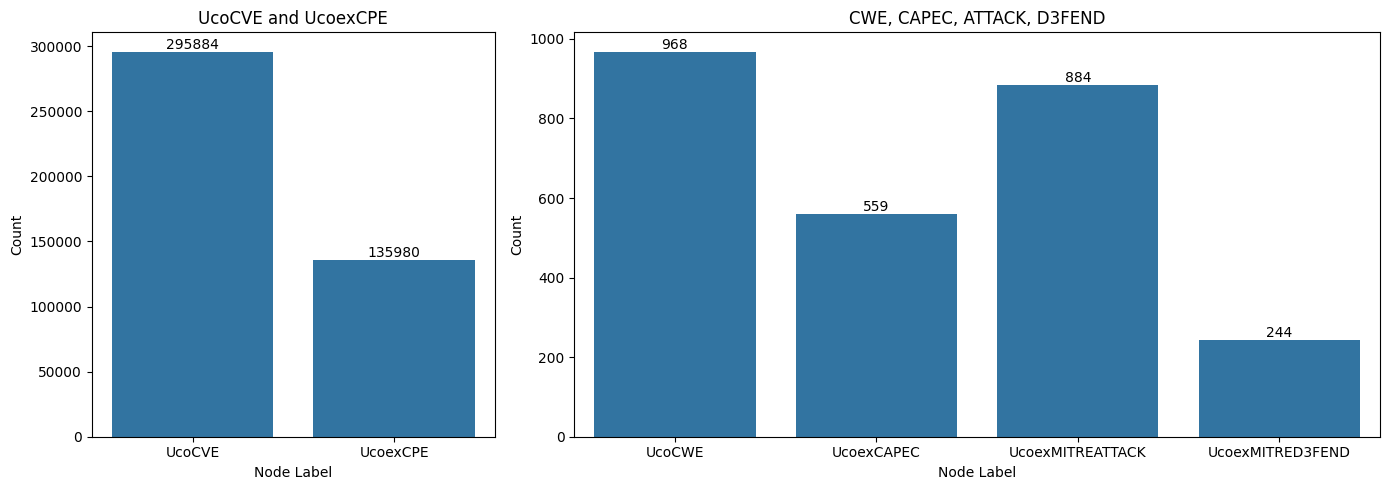

In [13]:
query = """
CALL {
  MATCH (n:UcoCVE) RETURN 'UcoCVE' AS label, count(n) AS count
  UNION
  MATCH (n:UcoCWE) RETURN 'UcoCWE' AS label, count(n) AS count
  UNION
  MATCH (n:UcoexCPE) RETURN 'UcoexCPE' AS label, count(n) AS count
  UNION
  MATCH (n:UcoexCAPEC) RETURN 'UcoexCAPEC' AS label, count(n) AS count
  UNION
  MATCH (n:UcoexMITREATTACK) RETURN 'UcoexMITREATTACK' AS label, count(n) AS count
  UNION
  MATCH (n:UcoexMITRED3FEND) RETURN 'UcoexMITRED3FEND' AS label, count(n) AS count
}
RETURN label, count
"""

results = run_query(query)
df = pd.DataFrame(results)

# Split data into two groups
group1_labels = ['UcoCVE', 'UcoexCPE']
group2_labels = ['UcoCWE', 'UcoexCAPEC', 'UcoexMITREATTACK', 'UcoexMITRED3FEND']

df_group1 = df[df['label'].isin(group1_labels)]
df_group2 = df[df['label'].isin(group2_labels)]

# Create horizontal plot with two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5), gridspec_kw={'width_ratios': [1, 2]})

# Plot Group 1
sns.barplot(data=df_group1, x='label', y='count', ax=ax1)
ax1.set_title("UcoCVE and UcoexCPE")
ax1.set_xlabel("Node Label")
ax1.set_ylabel("Count")
for p in ax1.patches:
    ax1.text(p.get_x() + p.get_width() / 2., p.get_height(), int(p.get_height()), 
             ha='center', va='bottom', fontsize=10)

# Plot Group 2
sns.barplot(data=df_group2, x='label', y='count', ax=ax2)
ax2.set_title("CWE, CAPEC, ATTACK, D3FEND")
ax2.set_xlabel("Node Label")
ax2.set_ylabel("Count")

for p in ax2.patches:
    ax2.text(p.get_x() + p.get_width() / 2., p.get_height(), int(p.get_height()), 
             ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

## Common Vulnerability Enumeration (CVE) and Common Vulnerability Severity Scores (CVSS)

CVE and CVSS are represented across two nodes: UcoVulnerability and UcoCVE. UcoCVE nodes represent real-world CVE records while UcoVulnerability contains general conceptual information of a vulnerability which is designed to enable semantic reasoning. As a result, these datasets are 1-to-1 in count and relationship.

In [ ]:
query = """
MATCH (n:UcoCVE) RETURN 'UcoCVE' AS label, count(n) AS count
UNION
MATCH (n:UcoVulnerability) RETURN 'UcoVulnerability' AS label, count(n) AS count
"""

params = {}
records = run_query(query, parameters=params)

df = pd.DataFrame(records)
df.style.set_table_styles(
    [{'selector': 'th', 'props': [('text-align', 'left')]}]
).set_properties(**{'text-align': 'left'})

query = """
MATCH (n:UcoCVE)
UNWIND keys(n) AS Attributes
RETURN DISTINCT Attributes
"""

params = {}
records = run_query(query, parameters=params)

# Convert to DataFrame and expand the dictionary of attributes into columns
df = pd.DataFrame(records)
attributes_expanded = df['attributes'].apply(pd.Series)
df_final = pd.concat([df.drop(columns='attributes'), attributes_expanded], axis=1)

# Stylized output
df_final.style.set_table_styles(
    [{'selector': 'th', 'props': [('text-align', 'left')]}]
).set_properties(**{'text-align': 'left'})

query = """
MATCH (n:UcoVulnerability)
UNWIND keys(n) AS Attributes
RETURN DISTINCT Attributes
"""

params = {}
records = run_query(query, parameters=params)

# Convert to DataFrame and expand the dictionary of attributes into columns
df = pd.DataFrame(records)
attributes_expanded = df['attributes'].apply(pd.Series)
df_final = pd.concat([df.drop(columns='attributes'), attributes_expanded], axis=1)

# Stylized output
df_final.style.set_table_styles(
    [{'selector': 'th', 'props': [('text-align', 'left')]}]
).set_properties(**{'text-align': 'left'})

KeyError: 'attributes'